У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [ ]:
!pip uninstall -y numpy darts

In [ ]:
!pip install numpy==1.26.4

In [ ]:
!pip install darts==0.34.0 --quiet

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
import numpy as np
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from darts import TimeSeries
from darts.utils.statistics import check_seasonality, plot_acf as darts_plot_acf
from darts.models import NaiveSeasonal, NaiveDrift
from darts.metrics import mape
from darts.models import XGBModel
from darts.models import Prophet
from darts.dataprocessing.transformers import Scaler
from darts.models import ExponentialSmoothing, AutoARIMA
from darts.utils.utils import SeasonalityMode
from darts.utils.utils import ModelMode
from darts.models import ARIMA
from darts.models import RNNModel
from statsmodels.tsa.statespace.sarimax import SARIMAX
from darts.utils.statistics import plot_residuals_analysis

In [3]:
data = pd.read_csv('train.csv.zip')
data.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)
data.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



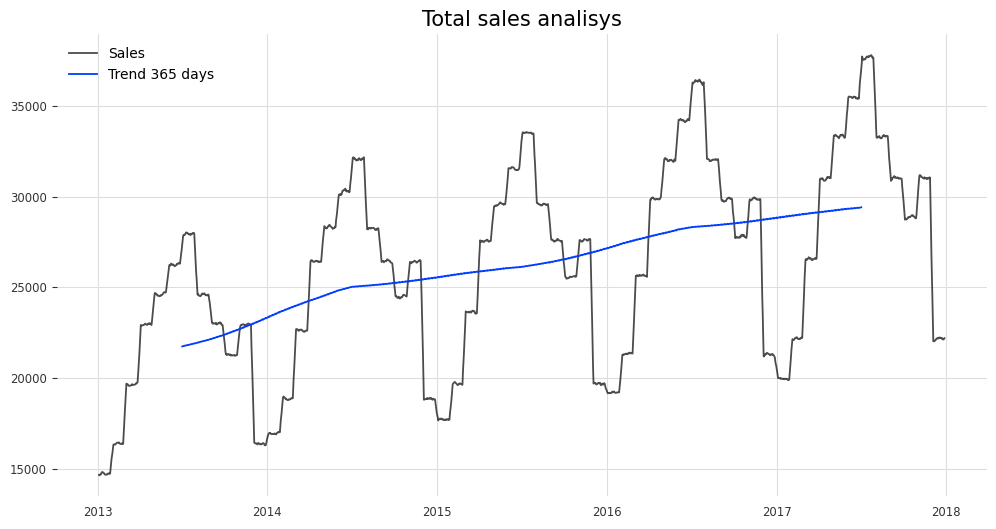

In [ ]:
trend_365 = data.groupby(data.index)['sales'].sum().rolling(window=365, center=True).mean()
sales_week = data.groupby(data.index)['sales'].sum().rolling(window=7, center=True).mean()

plt.figure(figsize=(12, 6))
plt.plot(sales_week, alpha=0.7, label='Sales')
plt.plot(trend_365, label='Trend 365 days')
plt.title('Total sales analisys', fontsize=15)
plt.legend()
plt.show()

**Аналіз динаміки сумарних продажів**
* **Загальна тенденція (Тренд):**
Графік демонструє стійкий позитивний довгостроковий тренд. Використання 365-денного ковзного середнього дозволило очистити дані від сезонності та підтвердити стабільне зростання бізнесу протягом 2013–2018 років.

* **Темпи зростання:**
Найбільш інтенсивне зростання обсягів продажів спостерігалося у 2013–2014 роках. Починаючи з 2015 року, темпи зростання дещо сповільнилися, що може свідчити про перехід бізнесу до стадії зрілості або насичення ринку.

* **Сезонність:**
У даних чітко простежується річна циклічність. Пік купівельної активності щороку припадає на літні місяці, після чого спостерігається прогнозований спад у зимовий період.

In [ ]:
store_daily = data.groupby([data.index, 'store'])['sales'].sum().reset_index()

store_daily['sales_smoothed'] = (
    store_daily.groupby('store')['sales']
    .transform(lambda x: x.rolling(window=14, min_periods=1, center=True).mean())
)

fig = px.line(
    store_daily,
    x='date',
    y='sales_smoothed',
    color='store',
    title='Interactive Store Sales Dynamics (Smoothed)',
    labels={'sales_smoothed': 'Sales', 'date': 'Date', 'store': 'Store'},
    template='plotly_white'
)

fig.update_layout(
        legend_title_text='Store ID'
)

fig.show()

**Аналіз динаміки продажів в розрізі магазинів**
* Для всіх десяти локацій характерна ідентична сезонна модель із чітким піком у літні місяці та щорічним зростанням загальних обсягів реалізації. Це свідчить про те, що зовнішні ринкові фактори та загальна стратегія розвитку компанії мають рівномірний вплив на всю мережу.

* Магазини №2, №8, №3 та №10 стабільно утримують статус лідерів за обсягами продажів протягом усього досліджуваного періоду. Їхня перевага зберігається незалежно від сезонних коливань.

* Сезонність та тренд зростання мають пропорційний вплив на всі об'єкти мережі. Порядок магазинів у рейтингу за обсягами продажів залишається практично незмінним рік у рік - лінії на графіку не перетинаються.

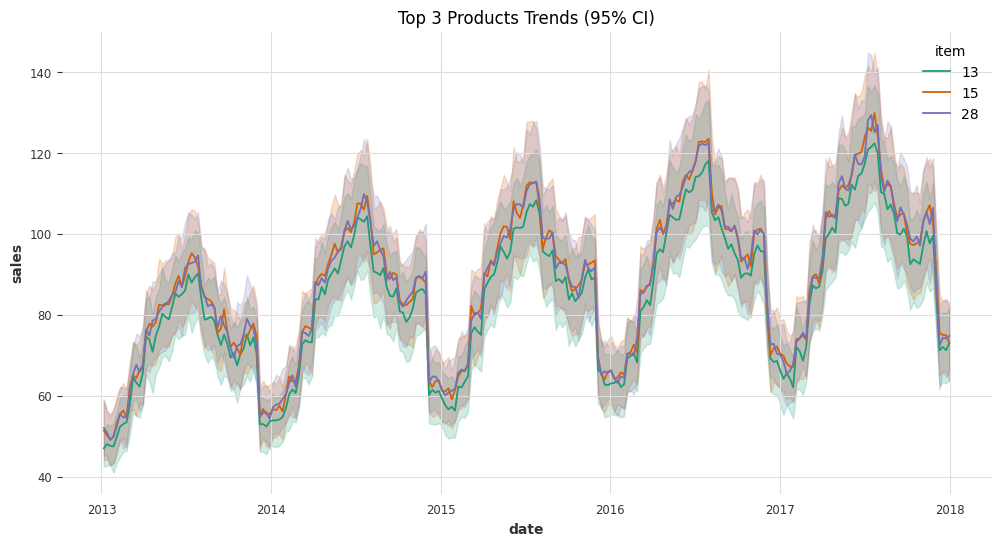

In [ ]:
data_resampled = data.groupby(['item', 'store'])['sales'].resample('W').mean().reset_index()
top3_items = (
    data.groupby('item')['sales']
    .sum()
    .nlargest(3)
    .index
)
subset_top3 = data_resampled[data_resampled['item'].isin(top3_items)]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=subset_top3,
    x='date',
    y='sales',
    hue='item',
    palette='Dark2',
    errorbar=('ci', 95))
plt.title('Top 3 Products Trends (95% CI)')
plt.show()

**Аналіз динаміки топ-3 товарів з 95% довірчим інтервалом**
* Товари 13, 15, 28 є найбільш популярними

* Довірчі інтервали всіх трьох товарів практично повністю накладаються один на одного, що свідчить про те, що вони однаково добре продаються.

* Ширина інтревалу не є надто великою, що свідчить про стабільність: товари є майже однаково популярні в усіх магазинах.

* Розширення довірчих інтервалів на піках сезонних коливань свідчить про те, що коли попит зростає, різниця між "сильними" і "слабкими" магазинами збільшується.

* Всі три товари мають ідентичні цикли - у них однакові дати злетів і падінь.

**Heat map для топ-3 товарів**

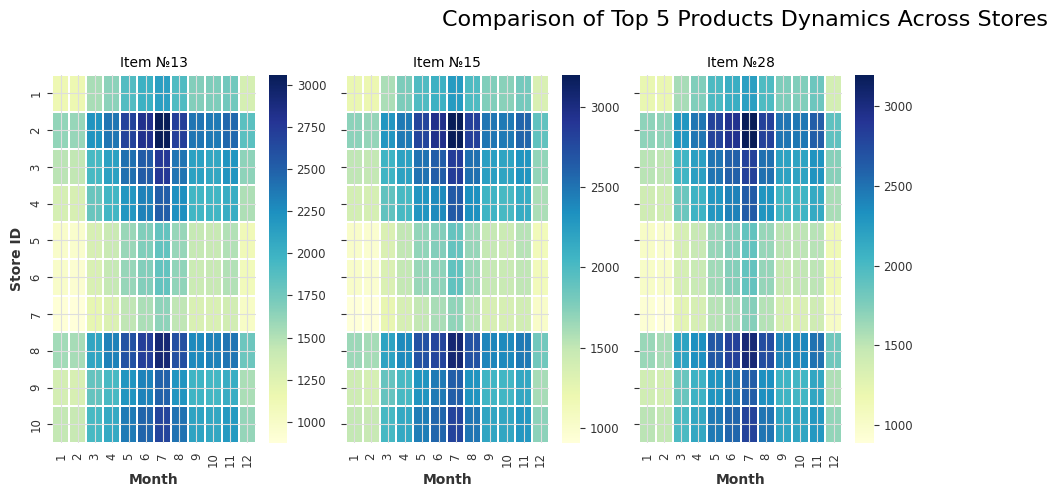

In [ ]:
heatmap_subset = subset_top3.copy()
heatmap_subset.set_index('date', inplace=True)
heatmap_subset['month'] = heatmap_subset.index.month

pivot_data = heatmap_subset.pivot_table(
    index=['item', 'store'],
    columns='month',
    values='sales',
    aggfunc='sum'
).reset_index()

long_data = pivot_data.melt(id_vars=['item', 'store'], var_name='month', value_name='sales')
long_data['month'] = long_data['month'].astype(int)

# Creating a grid: one column per product, total height 5 inches
g = sns.FacetGrid(long_data, col='item', col_wrap=5, height=5, aspect=0.6)

# Function to render a single heatmap per grid cell
def draw_heatmap(data, **kwargs):
    data_pivot = data.pivot(index='store', columns='month', values='sales')
    sns.heatmap(data_pivot, cmap='YlGnBu', linewidths=.1, **kwargs)

g.map_dataframe(draw_heatmap)

g.set_titles("Item №{col_name}")
g.set_axis_labels("Month", "Store ID")

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=90)

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Comparison of Top 5 Products Dynamics Across Stores', fontsize=16)

plt.show()

**Аналіз теплової карти продажів топ 3 товарів у розрізі магазинів і місяців**

* Теплова карта чітко виділяє групу магазинів із нижчим рівнем торговельної активності (№1, 5, 6 та 7). Протягом усього періоду спостережень ці локації демонструють стабільно менші обсяги продажів порівняно з іншими точками мережі, незалежно від товару

* Пік продажів припадає на літні місяці (червень–серпень), тоді як мінімальні показники зафіксовані у зимовий період (грудень–лютий). Це свідчить про універсальний характер попиту для всієї мережі.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

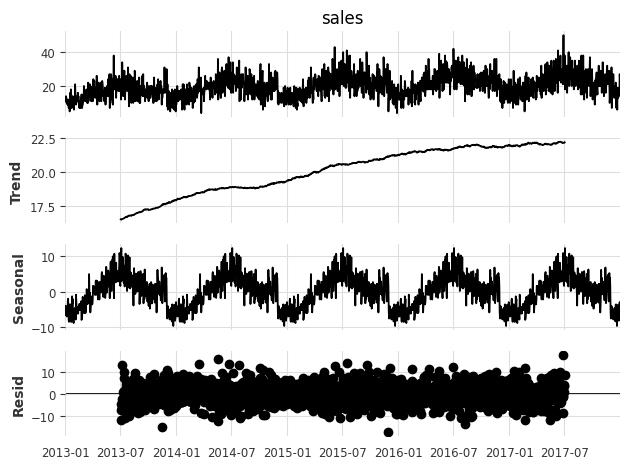

In [5]:
subset = data.loc[(data['item'] == 1) & (data['store'] == 1)]
decomposition_plot = seasonal_decompose(subset['sales'], model='additive', period=365)
decomposition_plot.plot()
plt.show()

In [ ]:
resids = decomposition_plot.resid
resids.dropna(inplace=True)
result = adfuller(resids,autolag='AIC')
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.586121
p-value: 0.000000
Critical Values:
	1%: -3.435
	5%: -2.864
	10%: -2.568


**Висновки з декомпозиції часового ряду:**

* **Тренд (Trend):** Спостерігається стійке нелінійне зростання продажів протягом усього періоду (з 2013 по 2017 роки). Це свідчить про загальне розширення ринку або зростання популярності товару/магазину.

**Сезонність (Seasonal):** На графіку з параметром period=365 чітко видно річну циклічність з піком у літні місяці та спадом у зимовий період.

**Залишки (Resid):** Залишки (резидуали) зосереджені навколо нуля і не мають видимого тренду, що є доброю ознакою. Проте вони мають "шумну" структуру, що вказує на наявність факторів, які не враховані адитивною моделлю за 365 днів.

**ADF тест:** Значення p-value ≈ 0.000 дозволяє відкинути нульову гіпотезу. Це означає, що залишки є стаціонарними. Це критично важливий результат: він підтверджує, що декомпозиція успішно "витягла" з даних основний тренд та сезонність, залишивши лише випадковий шум.

**Можливе покращення обробки даних**

* **Попереднє згладжування (Smoothing):** Початковий графік sales дуже "зубчастий" через щоденні коливання. Використання ковзного середнього (Rolling Average) за 7 днів допомогло б прибрати "білий шум" і чіткіше побачити тренд без дрібних перешкод.

* **Аналіз подвійної сезонності:** Треба з'ясувати чи немає іншої сезонності окрім річної. Можливо треба провести декомпозицію також з іншим періодом.

* **Виявлення викидів (Outliers):** Деякі точки в залишках виходять за межі загальної маси (понад 10 одиниць). Попередній пошук та обробка аномалій (наприклад, акційних днів чи свят) зробили б компоненти тренду та сезонності чистішими.

4. **Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.**

In [6]:
series = TimeSeries.from_dataframe(subset, value_cols='sales')

<Axes: xlabel='date'>

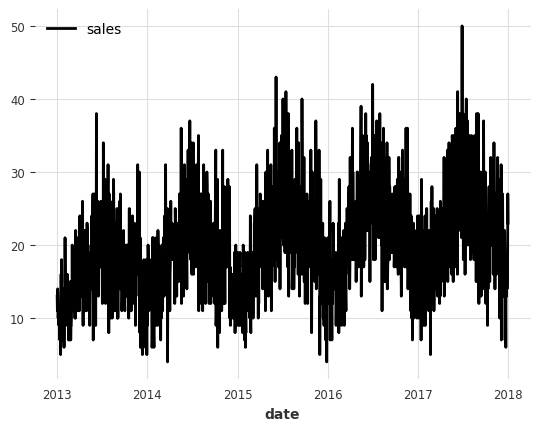

In [ ]:
series.plot()

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

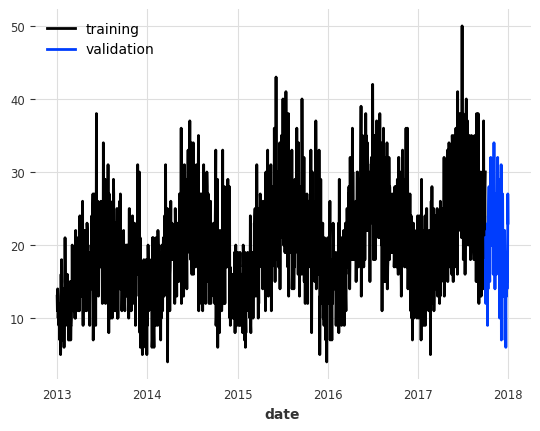

In [7]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
train.plot(label="training")
val.plot(label="validation")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1000x600 with 0 Axes>

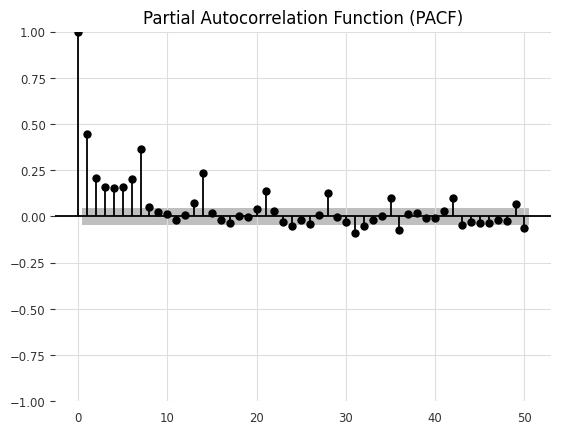

In [ ]:
# Візуалізація часткової автокореляційної функції (PACF)
plt.figure(figsize=(10, 6))
plot_pacf(subset['sales'], lags=50, method='ywm')
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

**Висновок з аналізу PACF:**
* **Короткострокова залежність (Lags 1, 2):** Лаги 1 та 2 є статистично значущими та позитивно корельованими. Це вказує на сильний авторегресійний ефект: поточні продажі безпосередньо залежать від показників за два попередні дні.
* **Тижнева циклічність (Lag 7):** Спостерігається чіткий сплеск на 7-му лагу, який виходить за межі довірчого інтервалу. Це є прямим підтвердженням тижневої сезонності продажів (поведінка покупців повторюється щотижня).

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

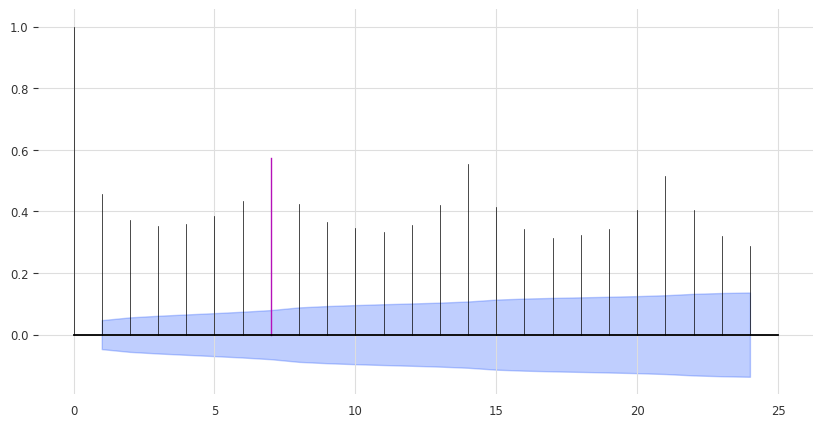

In [ ]:
darts_plot_acf(train, m=7, alpha=0.05, max_lag=24)

In [ ]:
for m in range(2, 25):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.


**Висновок:**

Графік ACF та функція check_seasonality підтверджують наявність сезонності порядків 7, 14 та 21. Це доводить, що тижневий цикл є домінуючим короткостроковим фактором.

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

<Axes: xlabel='date'>

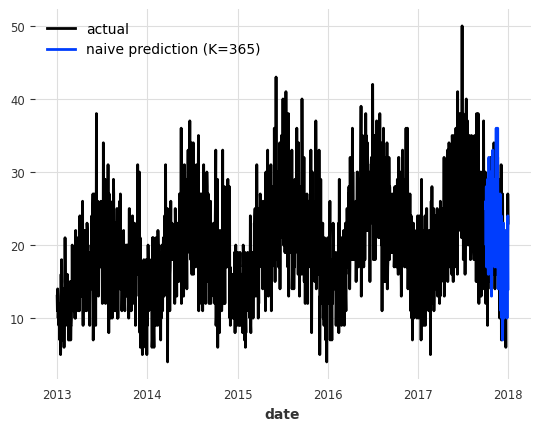

In [ ]:
seasonal_model = NaiveSeasonal(K=365)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(92)

series.plot(label="actual")
seasonal_forecast.plot(label="naive prediction (K=365)")

<Axes: xlabel='date'>

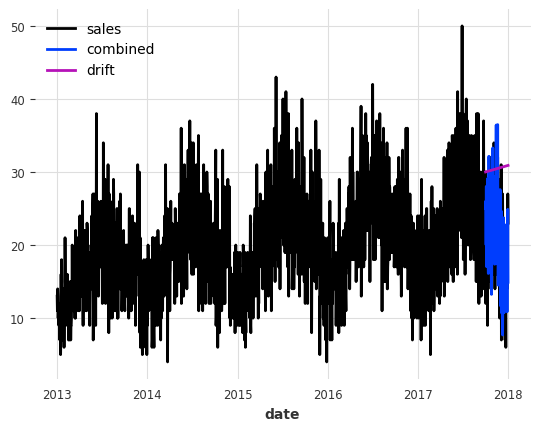

In [ ]:
drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(92)

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()

series.plot()
combined_forecast.plot(label="combined")
drift_forecast.plot(label="drift")

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [ ]:
print(
    f"Mean absolute percentage error for the combined naive drift + seasonal: {mape(series, combined_forecast):.2f}%."
)

Mean absolute percentage error for the combined naive drift + seasonal: 34.26%.


**Висновки щодо результатів наївного прогнозування (Combined Naive Drift + Seasonal)**

Розрахована помилка моделі становить **34.26%**. Хоча на перший погляд це значення може здатися високим, для щоденних даних (Daily Sales) на рівні окремого товару та магазину — це цілком адекватний і непоганий результат.

Через те що продажі в середньому коливаються в діапазоні від 10 до 40 одиниць, навіть невелика помилка в абсолютних одиницях (наприклад, 5 штук) дає значний відсоток помилки (від 12% до 50%).

Графік показує, що комбінована модель успішно «спіймала» дві ключові характеристики ряду: тренд (модель NaiveDrift коректно продовжує загальну лінію зростання продажів) та сезонність( Модель NaiveSeasonal відтворює тижневий паттерн, що відповідає реальній поведінці покупців)

**Побудована модель Naive Seasonal + Naive Drift слугує надійним Baseline (базовим рівнем). Це точка відліку: будь-яка складніша модель (ARIMA, Prophet або нейронні мережі) повинна показати MAPE нижче за 34%, щоб вважатися ефективною. Для "наївного" підходу модель працює стабільно і правильно інтерпретує структуру даних.**

10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [8]:
def eval_forecast(model, val, forecast):
  mape_ = mape(val, forecast)
  print(f"model {model} obtains MAPE: {mape_:.2f}%")
  return mape_

In [9]:
def enrich_with_date_features(df):
  #df["hour"] = df['Month'].dt.hour
  df["dayofweek"] = df['date'].dt.dayofweek
  df["quarter"] = df['date'].dt.quarter
  df["month"] = df['date'].dt.month
  df["year"] = df['date'].dt.year
  df["dayofyear"] = df['date'].dt.dayofyear
  df["sin_day"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
  df["cos_day"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)
  df["dayofmonth"] = df['date'].dt.day
  return df

In [10]:
# Додавання ознак дати
train_enriched = enrich_with_date_features(train.pd_dataframe().reset_index())
val_enriched = enrich_with_date_features(val.pd_dataframe().reset_index())

# Створюємо TimeSeries для таргету
train_series = TimeSeries.from_dataframe(train_enriched, time_col="date", value_cols="sales")
val_series = TimeSeries.from_dataframe(val_enriched, time_col="date", value_cols="sales")

# Створюємо TimeSeries для фіч
feature_cols = [col for col in train_enriched.columns if col not in ["date", "sales"]]
train_cov = TimeSeries.from_dataframe(train_enriched, time_col="date", value_cols=feature_cols)
val_cov = TimeSeries.from_dataframe(val_enriched, time_col="date", value_cols=feature_cols)

In [ ]:
# Для валідації : додоаємо декілька "контекстних" днів перед початком
val_start_date = val_enriched['date'].min()
extra_days = 7

val_cov_context_df = pd.concat([
    train_enriched[train_enriched['date'] >= val_start_date - pd.Timedelta(days=extra_days)],
    val_enriched
]).drop_duplicates('date')

val_cov_context = TimeSeries.from_dataframe(val_cov_context_df, time_col="date", value_cols=feature_cols)

model_XGB = XGBModel(
    lags=[-14],
    lags_past_covariates=[-1, -2, -7],
    output_chunk_length=7,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_XGB.fit(
    series=train_series,
    past_covariates=train_cov
)
forecast = model_XGB.predict(
    n=len(val),
    past_covariates=val_cov_context
)
forecast.values()

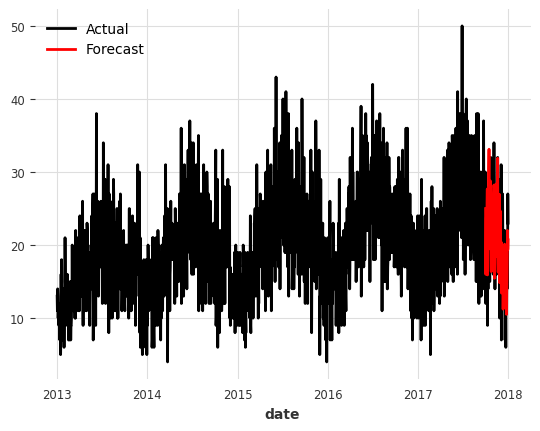

model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...) obtains MAPE: 23.92%


In [ ]:
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()
eval_forecast(model_XGB, val, forecast);

**Спостереження**

Застосування градієнтного бустингу XGBoost дозволило здійснити значний технологічний стрибок у якості прогнозу. Порівняно з наївною сезонною моделлю (Baseline), яка демонструвала помилку MAPE 34.26%, модель машинного навчання знизила цей показник до 23.92%. Покращення точності на ~11% свідчить про високу здатність алгоритму знаходити приховані закономірності в даних.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [11]:
def plot_results(series, forecast):
  series.plot(label='Actual')
  forecast.plot(label='Forecast', color='red')
  plt.legend()
  plt.show()

def fit_and_plot(model, series, train, val):
  model.fit(train)
  forecast = model.predict(len(val))
  plot_results(series, forecast)
  eval_forecast(model, val, forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


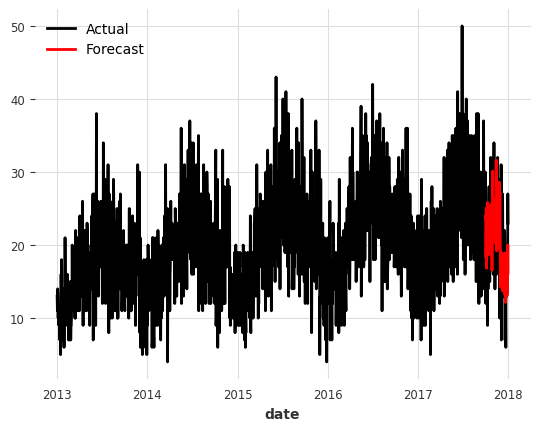

model ExponentialSmoothing(seasonal=SeasonalityMode.MULTIPLICATIVE, seasonal_periods=365, random_state=42) obtains MAPE: 27.83%


In [ ]:
model_Ex = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE,
    seasonal=SeasonalityMode.MULTIPLICATIVE,
    seasonal_periods=365,
    random_state=42)
fit_and_plot(model_Ex, series, train, val)

Не вдалося покращити результат передбачень з **ExponentialSmoothing**. Помилка більша ніж з **XBGModel**

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

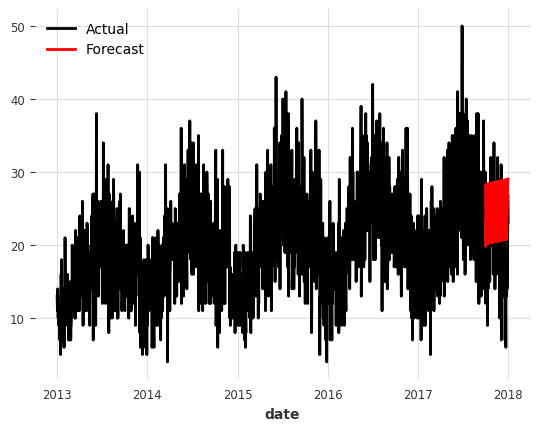

model ARIMA(p=2, q=1, seasonal_order=(1, 1, 1, 7)) obtains MAPE: 38.79%


In [ ]:
model_arima = ARIMA(
    p=2, d=1, q=1,
    seasonal_order=(1, 1, 1, 7)
)

fit_and_plot(model_arima, series, train, val)

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [13]:
model_AutoARIMA = AutoARIMA(
    start_p=1, max_p=3,
    start_q=1, max_q=3,
    seasonal=True,
    m=7,
    start_P=1, max_P=2,
    d=1,
    D=1,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore")

full_covariates = train_cov.concatenate(val_cov)

AutoARIMA(add_encoders=None, start_p=1, max_p=3, start_q=1, max_q=3, seasonal=True, m=7, start_P=1, max_P=2, d=1, D=1, stepwise=True, suppress_warnings=True, error_action=ignore)

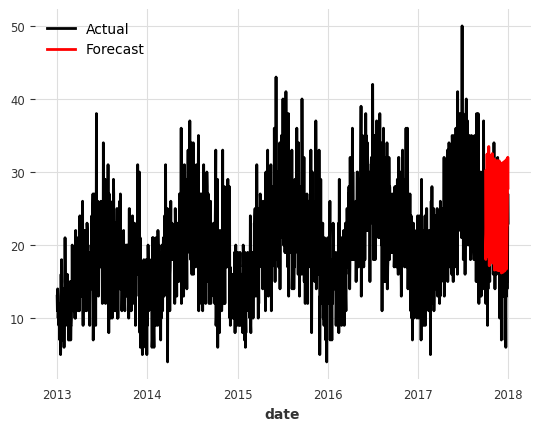

model AutoARIMA(start_p=1, max_p=3, start_q=1, max_q=3, seasonal=True, m=7, start_P=1, max_P=2, d=1, D=1, stepwise=True, suppress_warnings=True, error_action=ignore) obtains MAPE: 37.44%


37.442166407803775

In [ ]:
model_AutoARIMA.fit(train, future_covariates=full_covariates)

display(model_AutoARIMA)

# Прогнозування
forecast = model_AutoARIMA.predict(len(val), future_covariates=full_covariates)

plot_results(series, forecast)
eval_forecast(model_AutoARIMA, val, forecast)

In [ ]:
model_AutoARIMA.model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                 1734
Model:             SARIMAX(3, 1, 0)x(2, 1, 0, 7)   Log Likelihood               -5473.337
Date:                           Sun, 19 Apr 2026   AIC                          10974.674
Time:                                   09:34:20   BIC                          11051.024
Sample:                                        0   HQIC                         11002.917
                                          - 1734                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0001   2.08e+04  -6.84e-09      1.000   -4.08e+04    4.08e+04
x2             1.3701      1.087      1.261      0.207      -0.759       3.500
x3             9.0983     20.676      0.440      0.660     -31.425      49.622
x4          -470.3339     43.278    -10.868      0.000    -555.158    -385.510
x5            -1.5945      0.690     -2.312      0.021      -2.946      -0.243
x6            -3.2659     19.966     -0.164      0.870     -42.399      35.867
x7            -6.8404     19.354     -0.353      0.724     -44.773      31.092
x8             0.3153      0.678      0.465      0.642      -1.014       1.645
ar.L1         -0.7114      0.022    -32.893      0.000      -0.754      -0.669
ar.L2         -0.4913      0.025    -19.575      0.000      -0.541      -0.442
ar.L3         -0.2481      0.021    -11.809      0.000      -0.289      -0.207
ar.S.L7       -0.6347      0.022    -29.230      0.000      -0.677      -0.592
ar.S.L14      -0.2948      0.022    -13.397      0.000      -0.338      -0.252
sigma2        31.9065      1.049     30.414      0.000      29.850      33.963
===================================================================================
Ljung-Box (L1) (Q):                   6.73   Jarque-Bera (JB):                 2.38
Prob(Q):                              0.01   Prob(JB):                         0.30
Heteroskedasticity (H):               1.21   Skew:                             0.05
Prob(H) (two-sided):                  0.03   Kurtosis:                         3.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Модель AutoARIMA показала результат гірший ніж попередні експерименти(XGBoost і Exponential Smoothing)**

14. Натренуйте модель Prophet та зробіть висновок про її якість.

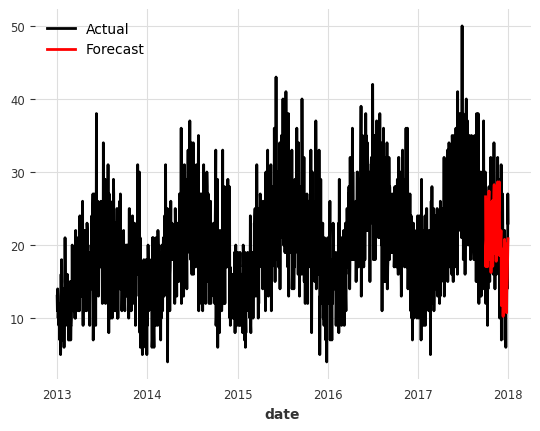

model Prophet(seasonality_mode=multiplicative, yearly_seasonality=20, weekly_seasonality=15, changepoint_prior_scale=0.1, seasonality_prior_scale=20.0) obtains MAPE: 22.93%


In [17]:
model_Prophet = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=20,
    weekly_seasonality=15,
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=20.0
    )
fit_and_plot(model_Prophet, series, train, val)

**Модель Prophet поки показала найкращі результати. На диний момент це наш фаворит**

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [20]:
scaler_sales = Scaler()
train_scaled = scaler_sales.fit_transform(train)
val_scaled = scaler_sales.transform(val)

scaler_cov = Scaler()
full_covariates_scaled = scaler_cov.fit_transform(full_covariates)

model_lstm = RNNModel(
    model="LSTM",
    hidden_dim=30,
    n_rnn_layers=2,
    input_chunk_length=30,
    training_length=45,
    dropout=0.1,
    batch_size=32,
    n_epochs=50,
    optimizer_kwargs={"lr": 1e-3},
    random_state=42,
    force_reset=True,
    pl_trainer_kwargs={
      "accelerator": "auto"
    }
)

model_lstm.fit(
    series=train_scaled,
    future_covariates=full_covariates_scaled,
    val_series=val_scaled,
    val_future_covariates=full_covariates_scaled,
    verbose=True
)

forecast_scaled = model_lstm.predict(n=len(val), future_covariates=full_covariates_scaled)

forecast_lstm = scaler_sales.inverse_transform(forecast_scaled)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │ 12.4 K │ train │     0 │
│ 6 │ V               │ Linear           │     31 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 12.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 12.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

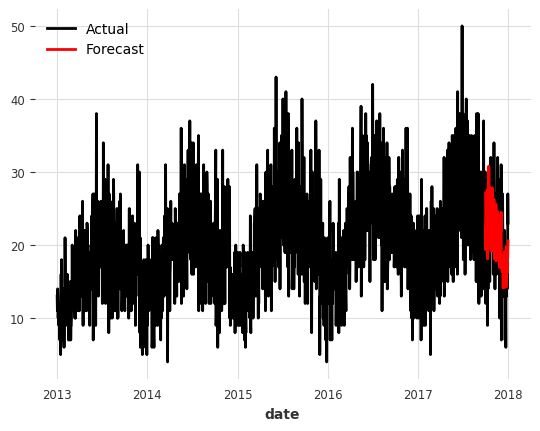

model RNNModel(model=LSTM, hidden_dim=30, n_rnn_layers=2, dropout=0.1, training_length=45, input_chunk_length=30, batch_size=32, n_epochs=50, optimizer_kwargs={'lr': 0.001}, random_state=42, force_reset=True, pl_trainer_kwargs={'accelerator': 'auto'}) obtains MAPE: 24.51%


24.505075985533416

In [21]:
# Візуалізація та оцінка
plot_results(series, forecast_lstm)
eval_forecast(model_lstm, val, forecast_lstm)

**Застосування нейронної мережі з архітектурою LSTM дозволило досягти показника MAPE 24.5%. Хоча LSTM зафіксована як одна з найбільш точних у проекті, проте Prophet та XGBoost показали кращі результати.**

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

historical forecasts: 100%|██████████| 12/12 [00:10<00:00,  1.14it/s]


MAPE = 20.84%


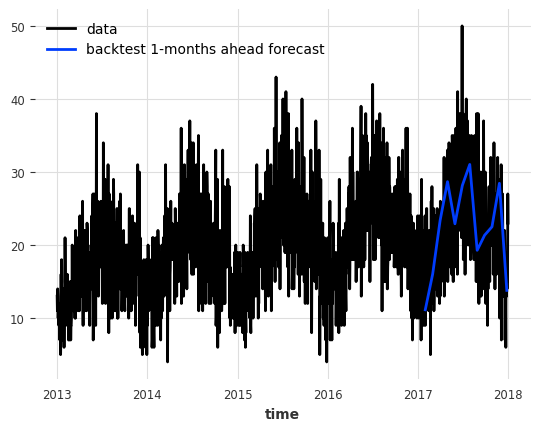

In [ ]:
hfc_params = {
    "series": series,
    "start": pd.Timestamp("2017-01-01"),  # can also be a float for the fraction of the series to start at
    "forecast_horizon": 30,
    "stride": 30,
    "retrain": True,
    "last_points_only": True,
    "verbose": True,
}

historical_fcast = model_Prophet.historical_forecasts(**hfc_params)

series.plot(label="data")
historical_fcast.plot(label="backtest 1-months ahead forecast")
print(f"MAPE = {mape(series, historical_fcast):.2f}%")

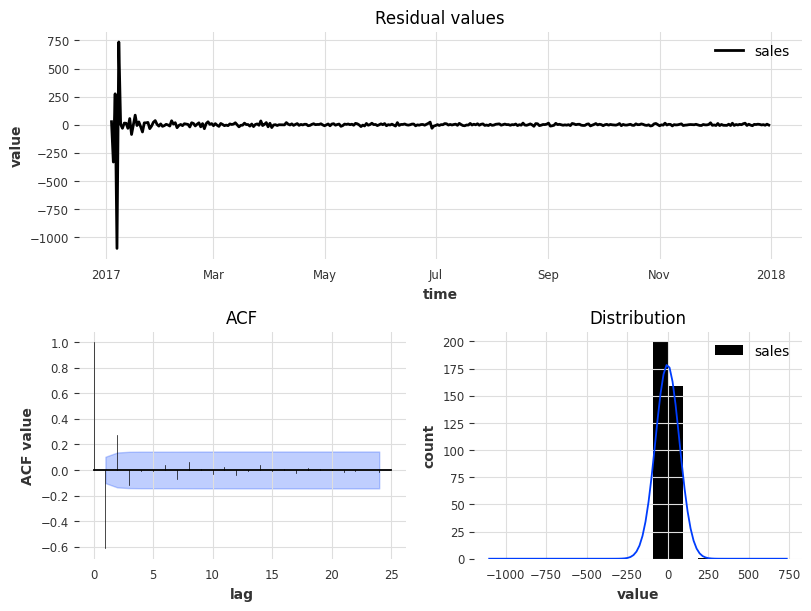

In [18]:
import logging
import warnings

logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

plot_residuals_analysis(model_Prophet.residuals(series[-365:]))

Для перевірки стійкості моделі Prophet було проведено два додаткових тести: бектестинг та аналіз залишків.

**Результати бектестингу**

Бектест проводився на даних за весь 2017 рік з горизонтом прогнозування 30 днів.

* **MAPE** бектесту: 20.84%.

* **Аналіз стабільності**: Показник точності на бектесті виявився навіть кращим за валідаційний, що свідчить про високу стабільність моделі та відсутність перенавчання. Модель впевнено відтворює річні та тижневі цикли продажів.

**Аналіз залишків (Residuals Analysis)**

Аналіз помилок моделі за останній рік дозволив підтвердити наступне:

* **Розподіл помилок**: Має форму, близьку до нормального розподілу (дзвоник), що вказує на відсутність систематичних зсувів у прогнозах.

* **Автокореляція (ACF)**: Майже всі лаги знаходяться всередині довірчого інтервалу (синя зона). Це доводить, що залишки є «білим шумом», а модель витягла з даних максимум корисної інформації.

* **Особливість ініціалізації**: Початковий «скачок» у залишках пояснюється ітераційним процесом адаптації алгоритму Prophet до нових даних на початку вікна спостереження і не впливає на підсумкову якість прогнозу.

**Загальний висновок**

На основі проведеного аналізу, модель Prophet з мультиплікативною сезонністю рекомендована як основний інструмент для прогнозування попиту. Вона забезпечує стабільну точність **(MAPE ~21%)**, успішно адаптується до трендів та сезонних коливань, а її помилки мають випадковий характер, що є ознакою статистично вірної моделі.

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

**Перспективи масштабування моделі (на 500 товарів/магазинів)**

1. Я б використала одну глобальну модель градієнтного бустингу (наприклад, LightGBM або XGBoost).

2. Я б тренувала лише одну модель для всіх 500 комбінацій товарів та магазинів одночасно.

3. Обґрунтування вибору:

   * Швидкість та ресурси: Тренувати 500 окремих моделей Prophet — це занадто довго та технічно складно. Одна модель бустингу обробляє всі дані за один прохід, що значно швидше.

   * Ефект взаємонавчання (Cross-learning): Глобальна модель бачить спільні патерни для всіх магазинів. Якщо якийсь товар у певному магазині продається рідко, модель «позичить» знання про його сезонність з інших магазинів, де він популярний. Це дає набагато точніший прогноз, ніж при навчанні кожного ряду окремо.

   * Гнучкість: Бустинг ідеально працює з наявними колонками store_id та item_id як з категоріальними ознаками, що дозволяє врахувати специфіку кожного магазину та товару в межах єдиного алгоритму.